# TITANIC SURVIVAL PREDICTION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv('train.csv')
print("Shape:", df.shape)

Shape: (891, 12)


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
print("Age missing values:", df['Age'].isnull().sum())

Age missing values: 0


C:\Users\prajn\AppData\Local\Temp\ipykernel_20600\1268613646.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [7]:
df.drop(columns=['Cabin'], inplace=True)
print("Cabin column removed!")

Cabin column removed!


In [8]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print("Embarked missing values:", df['Embarked'].isnull().sum())

Embarked missing values: 0


C:\Users\prajn\AppData\Local\Temp\ipykernel_20600\4060426907.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [9]:
print("Remaining missing values:")
print(df.isnull().sum())
print("\nDataset shape:", df.shape)

Remaining missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Dataset shape: (891, 11)


In [10]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
print("Unnecessary columns removed!")
print("Remaining columns:", df.columns.tolist())

Unnecessary columns removed!
Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [11]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
print(df['Sex'].value_counts())

Sex
0    577
1    314
Name: count, dtype: int64


In [12]:
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
print(df['Embarked'].value_counts())

Embarked
0    646
1    168
2     77
Name: count, dtype: int64


In [13]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [14]:
X = df.drop(columns=['Survived'])  # input features
y = df['Survived']                 # what we want to predict

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 7)
y shape: (891,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (712, 7)
Testing size: (179, 7)


In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
y_pred = model.predict(X_test)
print("Predictions made!")
print("First 10 predictions:", y_pred[:10])
print("Actual answers:      ", y_test[:10].values)

Predictions made!
First 10 predictions: [0 0 0 1 0 1 1 0 1 1]
Actual answers:       [1 0 0 1 1 1 1 0 1 1]


In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 82.12%


In [19]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

    Feature  Importance
5      Fare    0.272032
1       Sex    0.266227
2       Age    0.252044
0    Pclass    0.085496
3     SibSp    0.052776
4     Parch    0.037304
6  Embarked    0.034121


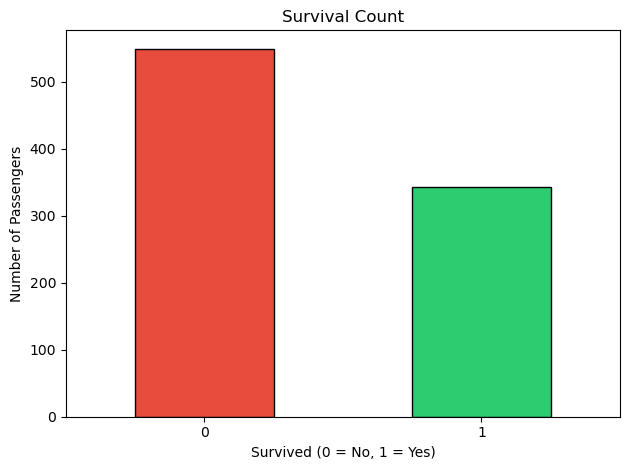

In [20]:
import matplotlib.pyplot as plt

df['Survived'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart1_survival_count.png')
plt.show()

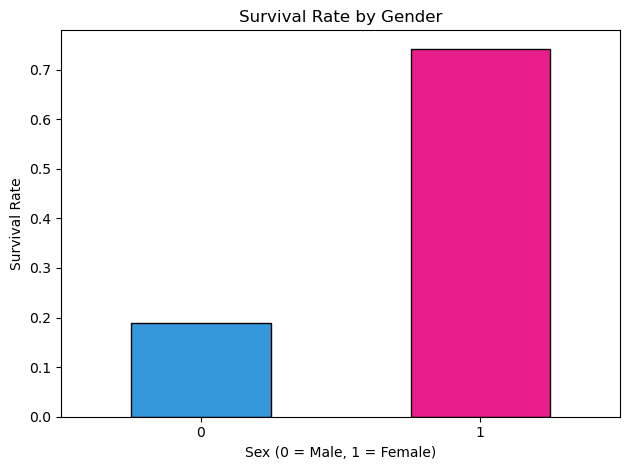

In [21]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['#3498db', '#e91e8c'], edgecolor='black')
plt.title('Survival Rate by Gender')
plt.xlabel('Sex (0 = Male, 1 = Female)')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart2_survival_by_gender.png')
plt.show()

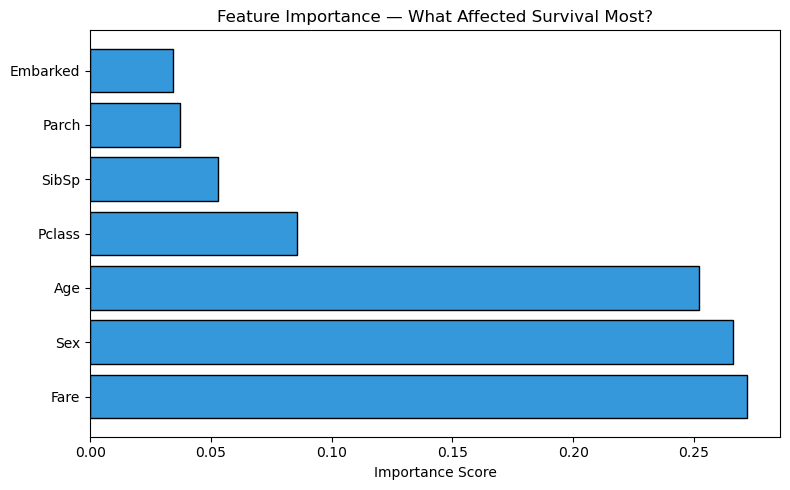

In [22]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='#3498db', edgecolor='black')
plt.title('Feature Importance — What Affected Survival Most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('chart3_feature_importance.png')
plt.show()

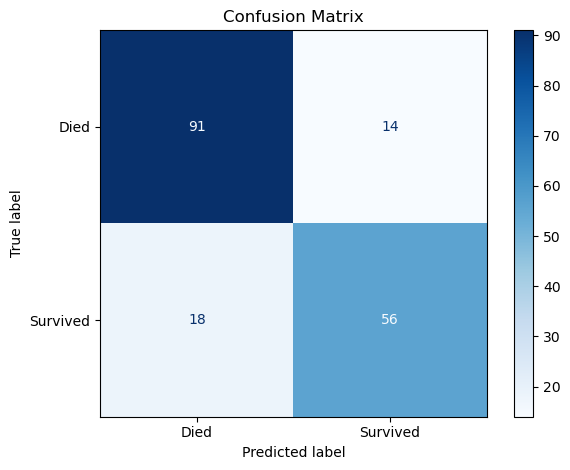

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('chart4_confusion_matrix.png')
plt.show()